In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import glob

In [2]:
# Files

priority_dict = {}

In [3]:
# Import the result files

baseline_path = glob.glob('baseline/*.csv')
for file in baseline_path:
    filename = file.split('.')[0].split('/')[1]
    priority_dict[filename[:-7]] = pd.read_csv(file)[:-1]

contrib_path = glob.glob('contrib/*.csv')
for file in contrib_path:
    filename = file.split('.')[0].split('/')[1]
    priority_dict[filename[:-7]] = pd.read_csv(file)[:-1]
    
discounted_path = glob.glob('discounted_contrib/*.csv')
for file in discounted_path:
    filename = file.split('.')[0].split('/')[1]
    priority_dict[filename[:-7]] = pd.read_csv(file)[:-1]
    
entropy_path = glob.glob('entropy/*.csv')
for file in entropy_path:
    filename = file.split('.')[0].split('/')[1]
    priority_dict[filename[:-7]] = pd.read_csv(file)[:-1]
    
fixed_path = glob.glob('fixed/*.csv')
for file in fixed_path:
    filename = file.split('.')[0].split('/')[1]
    priority_dict[filename[:-7]] = pd.read_csv(file)[:-1]
    
urgency_path = glob.glob('urgency/*.csv')
for file in urgency_path:
    filename = file.split('.')[0].split('/')[1]
    priority_dict[filename[:-7]] = pd.read_csv(file)[:-1]

In [4]:
# Columns we are interested in:
# Storage change and discharge; EV charge and discharge; Import and export

STORAGE_CHARGE = ['storage_{:02d}_charge'.format(i) for i in range(1, 21)]
STORAGE_CHARGE.remove('storage_04_charge')
STORAGE_CHARGE.remove('storage_14_charge')

STORAGE_DISCHARGE = ['storage_{:02d}_discharge'.format(i) for i in range(1, 21)]
STORAGE_DISCHARGE.remove('storage_04_discharge')
STORAGE_DISCHARGE.remove('storage_14_discharge')

STORAGE_DISCHARGE_EFF = ['storage_{:02d}_discharge_eff'.format(i) for i in range(1, 21)]
STORAGE_DISCHARGE_EFF.remove('storage_04_discharge_eff')
STORAGE_DISCHARGE_EFF.remove('storage_14_discharge_eff')

EV_CHARGE = ['ev_{:02d}_charge'.format(i) for i in range(1, 21)]
EV_CHARGE.remove('ev_04_charge')
EV_CHARGE.remove('ev_14_charge')

EV_DISCHARGE = ['ev_{:02d}_discharge'.format(i) for i in range(1, 21)]
EV_DISCHARGE.remove('ev_04_discharge')
EV_DISCHARGE.remove('ev_14_discharge')

EV_DISCHARGE_EFF = ['ev_{:02d}_discharge_eff'.format(i) for i in range(1, 21)]
EV_DISCHARGE_EFF.remove('ev_04_discharge_eff')
EV_DISCHARGE_EFF.remove('ev_14_discharge_eff')

COLUMNS_GRID = ['imports', 'exports', 'import_cost']

In [5]:
# Create a DF with sums

SEASONS = ['spring', 'summer', 'autumn', 'winter']
PRIORITY_TYPE = ['baseline', 'contrib', 'discounted_contrib', 'entropy', 'fixed', 'urgency']

COLS = ['storCharge', 'storDischarge', 'storDischargeEff', 'evCharge', 'evDischarge', 'evDischargeEff', 'imports', 'exports', 'importCost', 'exportCost']

MODE = ['training', 'testing']

RESULTS = {}

for mode in MODE:
    for season in SEASONS:
        temp_df = pd.DataFrame(index=PRIORITY_TYPE, columns=COLS)
        for priority in PRIORITY_TYPE:
            inner_df_ = priority_dict[f'{priority}_{mode}_{season}']
            temp_df.loc[priority, 'storCharge'] = inner_df_[STORAGE_CHARGE].sum().sum().round(2)
            temp_df.loc[priority, 'storDischarge'] = inner_df_[STORAGE_DISCHARGE].sum().sum().round(2)
            temp_df.loc[priority, 'storDischargeEff'] = inner_df_[STORAGE_DISCHARGE_EFF].sum().sum().round(2)
            temp_df.loc[priority, 'evCharge'] = inner_df_[EV_CHARGE].sum().sum().round(2)
            temp_df.loc[priority, 'evDischarge'] = inner_df_[EV_DISCHARGE].sum().sum().round(2)
            temp_df.loc[priority, 'evDischargeEff'] = inner_df_[EV_DISCHARGE_EFF].sum().sum().round(2)
            temp_df.loc[priority, 'imports'] = inner_df_['imports'].sum()
            temp_df.loc[priority, 'exports'] = inner_df_['exports'].sum()
            temp_df.loc[priority, 'importCost'] = (inner_df_['imports'] * inner_df_['import_cost']).sum()
            temp_df.loc[priority, 'exportCost'] = (inner_df_['exports'] * 0.04).sum()
            
        RESULTS[f'{mode}_{season}'] = temp_df

In [6]:
from src.resources import Vehicle, Generator, Load, Storage, Aggregator
from src.parsers import HMParser, CotevParser

# General data
N_HOUSES = 20
N_STEPS = 24 * 366 * 4  # 14496  # 6576  # 24 * 366
# 1 year - 2020 (leap year), 4 because we are using 15 minutes intervals

# EC data for mostly cost values
data_ec = HMParser(file_path='../../../data/EC_V4.xlsx', ec_id=1)
data_ec.parse()

# EV data from the EV4EU simulator
data_ev = CotevParser(population_path=
                      '../../../data/simulation_20evs_1year_15t/population_366.csv',
                      driving_history_path=
                      '../../../data/simulation_20evs_1year_15t/ev_driving_history_366.csv',
                      assigned_segments_path=
                      '../../../data/simulation_20evs_1year_15t/assigned_segments_366.csv',
                      parse_date_start='2020',
                      parse_date_end='2020')
data_ev.parse()

temp_costs_df = pd.DataFrame({'cost_parameter_b': data_ec.generator['cost_parameter_b'][0, 0],
                              'cost_nde': data_ec.generator['cost_nde'][0],
                              'cost_cut': data_ec.load['cost_cut'][0],
                              'cost_reduce': data_ec.load['cost_reduce'][0],
                              'cost_ens': data_ec.load['cost_ens'][0],
                              'discharge_price': np.array(data_ec.storage['discharge_price'][2]),
                              'charge_price': np.array(data_ec.storage['charge_price'][0]),
                              'import_contracted_p_max': 200,
                              'export_contracted_p_max': 200,
                              'buy_price': data_ec.peers['buy_price'][0],
                              'sell_price': data_ec.peers['sell_price'][0]},
                             index=pd.date_range(start='2020-01-01', freq='H', periods=24))
# Resample to 15T and forward fill the values
temp_costs_df = temp_costs_df.resample('15T').ffill()
# print('Initial costs DataFrame:\n{}'.format(temp_costs_df))

# Now fill the remaining 3 timestamps
temp_costs_df = temp_costs_df.reindex(pd.date_range(start='2020-01-01', freq='15T', periods=96), method='ffill')

aux_date_range = pd.date_range(start='2020-01-01', freq='15T', periods=N_STEPS)
winter_start = 0
winter_end = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 2].max())
spring_start = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 3].min())
spring_end = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 5].max())
summer_start = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 6].min())
summer_end = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 8].max())
autumn_start = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 9].min())
autumn_end = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 11].max())

# Seasonal splits
modes = [True, False]
data = {}

for mode in MODE:
    for season in SEASONS:
        SEASON_START = 0
        SEASON_END = 0
        
        if mode == 'training':
            if season == 'winter':
                N_STEPS = winter_end - winter_start - 1344
                SEASON_START = winter_start
                SEASON_END = winter_end - 1344
            elif season == 'spring':
                N_STEPS = spring_end - spring_start - 1344
                SEASON_START = spring_start
                SEASON_END = spring_end - 1344
            elif season == 'summer':
                N_STEPS = summer_end - summer_start - 1344
                SEASON_START = summer_start
                SEASON_END = summer_end - 1344
            elif season == 'autumn':
                N_STEPS = autumn_end - autumn_start - 1344
                SEASON_START = autumn_start
                SEASON_END = autumn_end - 1344
        else:
            if season == 'winter':
                N_STEPS = 1344
                SEASON_START = winter_end - 1344
                SEASON_END = winter_end
            elif season == 'spring':
                N_STEPS = 1344
                SEASON_START = spring_end - 1344
                SEASON_END = spring_end
            elif season == 'summer':
                N_STEPS = 1344
                SEASON_START = summer_end - 1344
                SEASON_END = summer_end
            elif season == 'autumn':
                N_STEPS = 1344
                SEASON_START = autumn_end - 1344
                SEASON_END = autumn_end

        # Create the generator and load lists to add on to
        generators = []
        loads = []
        used_idx = []
        
        for i in range(1, 21):
            temp_data = pd.read_csv('../../../data/housedata/W/H{}_W.csv'.format(i))
        
            # Fill the generator and load missing data with zeros
            temp_data = temp_data.fillna(0)
        
            # Resample to 1H intervals
            temp_data['date'] = pd.to_datetime(temp_data['date'])
            temp_data = temp_data.set_index('date', drop=True)
            temp_data = temp_data.resample('15T').mean()
        
            # Convert to kWh
            temp_data[' Production(kW)'] = temp_data[' Production(W)'] / 1000
            temp_data[' Consumption(kW)'] = temp_data[' Consumption(W)'] / 1000
        
            # Check if there are enough data points
            if temp_data.shape[0] < 366 * 96:
                print(f'Not enough data for house {i}, skipping...')
                continue
        
            # Create the generator
            generators.append(Generator(name='ren_generator_{:02d}'.format(i),
                                        value=np.zeros(N_STEPS),
                                        lower_bound=np.zeros(N_STEPS),
                                        upper_bound=temp_data[' Production(kW)'][SEASON_START:SEASON_END],
                                        cost=np.tile(temp_costs_df['cost_parameter_b'], (int(N_STEPS / 95)))[:-1],
                                        cost_nde=np.tile(temp_costs_df['cost_nde'], (int(N_STEPS / 95)))[:-1],
                                        is_renewable=True))
        
            # Create the load
            loads.append(Load(name='load_{:02d}'.format(i),
                              value=temp_data[' Consumption(kW)'][SEASON_START:SEASON_END],
                              lower_bound=np.zeros(N_STEPS),
                              upper_bound=temp_data[' Consumption(kW)'][SEASON_START:SEASON_END],
                              cost=np.ones(N_STEPS),
                              cost_cut=np.tile(temp_costs_df['cost_cut'], (int(N_STEPS / 95)))[:-1],
                              cost_reduce=np.tile(temp_costs_df['cost_reduce'], (int(N_STEPS / 95)))[:-1],
                              cost_ens=np.tile(temp_costs_df['cost_ens'], (int(N_STEPS / 95)))[:-1]))
        
            used_idx.append(i - 1)  # Store the index of the house used
        
        # Create the storages
        storages = []
        for i in used_idx:
            storages.append(Storage(name='storage_{:02d}'.format(i + 1),
                                    value=np.tile(8.0, N_STEPS),
                                    lower_bound=np.tile(2.0, N_STEPS),
                                    upper_bound=np.tile(10.0, N_STEPS),
                                    cost=np.zeros(N_STEPS),
                                    cost_discharge=np.tile(temp_costs_df['discharge_price'], (int(N_STEPS / 95)))[:-1],
                                    cost_charge=np.tile(temp_costs_df['charge_price'], (int(N_STEPS / 95)))[:-1],
                                    capacity_max=10.0,
                                    capacity_min=2.0,  # 0.2 * capacity_max
                                    initial_charge=8.0,
                                    discharge_efficiency=0.95,
                                    discharge_max=np.tile(3.3, N_STEPS),
                                    charge_efficiency=0.95,
                                    charge_max=np.tile(3.3, N_STEPS),
                                    capital_cost=np.array([0.05250, 0.10500, 0.01575])))
        
        # EVs are already in the data_ev.resources, but we'll trim the excess data
        evs = []
        for i in used_idx:
            temp_res = data_ev.resources[i]
            evs.append(Vehicle(name='ev_{:02d}'.format(i + 1),
                               value=temp_res.value[SEASON_START:SEASON_END],
                               lower_bound=temp_res.lower_bound[SEASON_START:SEASON_END],
                               upper_bound=temp_res.upper_bound[SEASON_START:SEASON_END],
                               cost=temp_res.cost[SEASON_START:SEASON_END],
                               cost_discharge=temp_res.cost_discharge[SEASON_START:SEASON_END],
                               cost_charge=temp_res.cost_charge[SEASON_START:SEASON_END],
                               capacity_max=temp_res.capacity_max,
                               initial_charge=temp_res.initial_charge,
                               min_charge=temp_res.min_charge,
                               discharge_efficiency=temp_res.discharge_efficiency,
                               charge_efficiency=temp_res.charge_efficiency,
                               schedule_connected=temp_res.schedule_connected[SEASON_START:SEASON_END],
                               schedule_discharge=temp_res.schedule_discharge[SEASON_START:SEASON_END],
                               schedule_charge=temp_res.schedule_charge[SEASON_START:SEASON_END],
                               schedule_requirement_soc=temp_res.schedule_requirement_soc[SEASON_START:SEASON_END],
                               schedule_arrival_soc=temp_res.schedule_arrival_soc[SEASON_START:SEASON_END]))
        
        # Create the aggregator
        aggregator = Aggregator(name='aggregator',
                                value=np.zeros(N_STEPS),
                                lower_bound=np.zeros(N_STEPS),
                                upper_bound=np.tile(temp_costs_df['import_contracted_p_max'], (int(N_STEPS / 95)))[:-1],
                                cost=np.tile(data_ec.peers['buy_price'], (int(N_STEPS / 95)))[:-1],
                                imports=np.zeros(N_STEPS),
                                exports=np.zeros(N_STEPS),
                                import_cost=np.tile(temp_costs_df['buy_price'] * 2, (int(N_STEPS / 95)))[:-1],
                                export_cost=np.tile(temp_costs_df['sell_price'], (int(N_STEPS / 95)))[:-1],
                                import_max=np.tile(temp_costs_df['import_contracted_p_max'], (int(N_STEPS / 95)))[:-1],
                                export_max=np.tile(temp_costs_df['export_contracted_p_max'], (int(N_STEPS / 95)))[:-1])
        
        temp_data = {'gens': generators, 'loads': loads, 'stors': storages, 'evs': evs, 'aggregator': aggregator}
        data[f'{mode}_{season}'] = temp_data

2025-12-02 19:06:25,662	WARNING deprecation.py:50 -- DeprecationWarning: `DirectStepOptimizer` has been deprecated. This will raise an error in the future!
2025-12-02 19:06:26,260	WARNING deprecation.py:50 -- DeprecationWarning: `build_tf_policy` has been deprecated. This will raise an error in the future!
2025-12-02 19:06:26,262	WARNING deprecation.py:50 -- DeprecationWarning: `build_policy_class` has been deprecated. This will raise an error in the future!


Not enough data for house 4, skipping...
Not enough data for house 14, skipping...
Not enough data for house 4, skipping...
Not enough data for house 14, skipping...
Not enough data for house 4, skipping...
Not enough data for house 14, skipping...
Not enough data for house 4, skipping...
Not enough data for house 14, skipping...
Not enough data for house 4, skipping...
Not enough data for house 14, skipping...
Not enough data for house 4, skipping...
Not enough data for house 14, skipping...
Not enough data for house 4, skipping...
Not enough data for house 14, skipping...
Not enough data for house 4, skipping...
Not enough data for house 14, skipping...


In [7]:
# Calculate SS and SC

RESULTS_SS_SC = {}
for mode in MODE:
    for season in SEASONS:
        temp_data = pd.DataFrame(index=PRIORITY_TYPE, columns=['ss', 'sc'])
        total_loads_ = np.array([i.value.sum() for i in data[f'{mode}_{season}']['loads']]).sum()
        total_gens_ = np.array([i.value.sum() for i in data[f'{mode}_{season}']['gens']]).sum()
        for priority in PRIORITY_TYPE:
            # SS = (total_consumption - imports) / total_consumption
            # total_consumption = loads + storCharge + evCharge
            total_consumption_ = total_loads_ + RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'storCharge'] + RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'evCharge']
            temp_data.loc[priority, 'ss'] = (total_consumption_ - RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'imports']) / total_consumption_
            
            total_production_ = total_gens_ + RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'storDischargeEff'] + RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'evDischargeEff']
            temp_data.loc[priority, 'sc'] = (total_production_ - RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'exports']) / total_production_
            
        RESULTS_SS_SC[f'{mode}_{season}'] = temp_data

/var/folders/th/r7sxqq0x56d07db0rvxmgxdc0000gn/T/ipykernel_1021/3859865662.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  temp_data.loc[priority, 'sc'] = (total_production_ - RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'exports']) / total_production_
/var/folders/th/r7sxqq0x56d07db0rvxmgxdc0000gn/T/ipykernel_1021/3859865662.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  temp_data.loc[priority, 'sc'] = (total_production_ - RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'exports']) / total_production_
/var/folders/th/r7sxqq0x56d07db0rvxmgxdc0000gn/T/ipykernel_1021/3859865662.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  temp_data.loc[priority, 'sc'] = (total_production_ - RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'exports']) / total_production_
/var/folders/th/r7sxqq0x56d07db0rvxmgxdc0000gn/T/ipykernel_1021/3859865662.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  temp_data.loc[priority, 'sc'

In [8]:
RESULTS_SS_SC['testing_winter'].sort_values(by='sc', ascending=False)

,ss,sc
urgency,0.155289,0.983101
discounted_contrib,0.153475,0.981273
contrib,0.155236,0.979611
fixed,0.152496,0.977998
entropy,0.158087,0.977138
baseline,0.093835,-inf


In [9]:
RESULTS['training_spring'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,10269.420000,509.655462,9633.970000,10066.090000,10082.970000,10652.530000,10911.540000
storDischarge,5.0,9349.740000,456.733868,8778.770000,9168.460000,9182.560000,9697.810000,9921.100000
storDischargeEff,5.0,9841.832000,480.770847,9240.810000,9651.010000,9665.860000,10208.220000,10443.260000
evCharge,5.0,20528.564000,1254.174408,18294.940000,20887.540000,21113.220000,21171.160000,21175.960000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,75833.695039,1163.817288,73769.870233,76102.158168,76349.486564,76443.927964,76503.032265
exports,5.0,253.581953,131.513947,181.375400,185.119900,203.997600,209.557200,487.859667
importCost,5.0,13192.614061,303.705981,12687.156040,13144.705213,13307.291601,13382.032804,13441.884647
exportCost,5.0,10.143278,5.260558,7.255016,7.404796,8.159904,8.382288,19.514387


In [10]:
RESULTS['training_spring'].sort_values(by='exportCost', ascending=False)

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,55960.258,1828.386533,9459.377436,73.135461
discounted_contrib,9633.97,8778.77,9240.81,18294.94,0.0,0.0,73769.870233,487.859667,12687.15604,19.514387
urgency,10911.54,9921.1,10443.26,21171.16,0.0,0.0,76503.032265,209.5572,13307.291601,8.382288
contrib,10082.97,9182.56,9665.86,21113.22,0.0,0.0,76349.486564,203.9976,13441.884647,8.159904
fixed,10066.09,9168.46,9651.01,20887.54,0.0,0.0,76102.158168,185.1199,13144.705213,7.404796
entropy,10652.53,9697.81,10208.22,21175.96,0.0,0.0,76443.927964,181.3754,13382.032804,7.255016


In [11]:
RESULTS_SS_SC['testing_winter'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ss,5.0,0.154916,0.002135,0.152496,0.153475,0.155236,0.155289,0.158087
sc,5.0,0.979824,0.002420,0.977138,0.977998,0.979611,0.981273,0.983101


In [12]:
# Create the sum of energy required for the trips

training_spring_ev = np.array([ev.schedule_requirement_soc.sum() for ev in data['training_spring']['evs']]).sum()
training_spring_ev

20439.394879999993

In [13]:
sum([i.value.sum() for i in data['training_spring']['loads']])

71492.03993333333

In [15]:
RESULTS['training_summer']

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,53948.834867,1788.1068,9193.662221,71.524272
contrib,10469.65,9531.72,10033.39,21038.36,0.0,0.0,74278.203864,141.187201,13041.81619,5.647488
discounted_contrib,10054.2,9158.47,9640.49,21048.1,0.0,0.0,74340.584868,236.0218,13150.870685,9.440872
entropy,10852.85,9874.7,10394.42,21018.35,0.0,0.0,74316.790236,159.561867,12923.785231,6.382475
fixed,11010.5,10014.4,10541.48,21046.14,0.0,0.0,74441.679867,238.7141,13117.312927,9.548564
urgency,10700.51,9737.53,10250.03,21048.13,0.0,0.0,74381.516763,209.6767,13188.008962,8.387068


In [16]:
# Create the sum of energy required for the trips

training_summer_ev = np.array([ev.schedule_requirement_soc.sum() for ev in evs]).sum()
training_summer_ev

3657.3004399999986

In [17]:
RESULTS['training_summer'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,10617.542000,372.792096,10054.200000,10469.650000,10700.510000,10852.850000,11010.500000
storDischarge,5.0,9663.364000,333.780567,9158.470000,9531.720000,9737.530000,9874.700000,10014.400000
storDischargeEff,5.0,10171.962000,351.351111,9640.490000,10033.390000,10250.030000,10394.420000,10541.480000
evCharge,5.0,21039.816000,12.655526,21018.350000,21038.360000,21046.140000,21048.100000,21048.130000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,74351.755120,62.708294,74278.203864,74316.790236,74340.584868,74381.516763,74441.679867
exports,5.0,197.032333,44.553740,141.187201,159.561867,209.676700,236.021800,238.714100
importCost,5.0,13084.358799,104.698264,12923.785231,13041.816190,13117.312927,13150.870685,13188.008962
exportCost,5.0,7.881293,1.782150,5.647488,6.382475,8.387068,9.440872,9.548564


In [18]:
RESULTS['training_autumn']

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,58953.7534,1941.769867,10107.201557,77.670795
contrib,10246.99,9333.42,9824.65,20926.6,0.0,0.0,79039.181331,187.026101,13694.368301,7.481044
discounted_contrib,10177.31,9260.75,9748.15,20250.57,0.0,0.0,78356.367565,177.243133,13633.023919,7.089725
entropy,10372.49,9440.13,9936.98,20733.8,0.0,0.0,78863.856835,185.7058,13831.940845,7.428232
fixed,10487.24,9541.93,10044.14,20950.16,0.0,0.0,79072.200032,164.7465,13876.019629,6.58986
urgency,10631.46,9682.36,10191.96,17512.76,0.0,0.0,75924.313266,450.470533,13308.365781,18.018821


In [19]:
# Create the sum of energy required for the trips

training_autumn_ev = np.array([ev.schedule_requirement_soc.sum() for ev in evs]).sum()
training_autumn_ev

3657.3004399999986

In [20]:
RESULTS['training_autumn'].sort_values(by='exportCost', ascending=False)

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,58953.7534,1941.769867,10107.201557,77.670795
urgency,10631.46,9682.36,10191.96,17512.76,0.0,0.0,75924.313266,450.470533,13308.365781,18.018821
contrib,10246.99,9333.42,9824.65,20926.6,0.0,0.0,79039.181331,187.026101,13694.368301,7.481044
entropy,10372.49,9440.13,9936.98,20733.8,0.0,0.0,78863.856835,185.7058,13831.940845,7.428232
discounted_contrib,10177.31,9260.75,9748.15,20250.57,0.0,0.0,78356.367565,177.243133,13633.023919,7.089725
fixed,10487.24,9541.93,10044.14,20950.16,0.0,0.0,79072.200032,164.7465,13876.019629,6.58986


In [21]:
RESULTS['training_autumn'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,10383.098000,182.699109,10177.310000,10246.990000,10372.490000,10487.240000,10631.460000
storDischarge,5.0,9451.718000,167.280762,9260.750000,9333.420000,9440.130000,9541.930000,9682.360000
storDischargeEff,5.0,9949.176000,176.088864,9748.150000,9824.650000,9936.980000,10044.140000,10191.960000
evCharge,5.0,20074.778000,1459.541317,17512.760000,20250.570000,20733.800000,20926.600000,20950.160000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,78251.183806,1331.893963,75924.313266,78356.367565,78863.856835,79039.181331,79072.200032
exports,5.0,233.038413,121.871997,164.746500,177.243133,185.705800,187.026101,450.470533
importCost,5.0,13668.743695,224.388829,13308.365781,13633.023919,13694.368301,13831.940845,13876.019629
exportCost,5.0,9.321537,4.874880,6.589860,7.089725,7.428232,7.481044,18.018821


In [22]:
RESULTS['training_winter']

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,37341.892733,521.378733,6441.591572,20.855149
contrib,6002.6,5497.17,5786.5,12614.68,0.0,0.0,50017.998867,77.373167,8878.71346,3.094927
discounted_contrib,5684.73,5217.03,5491.62,12614.66,0.0,0.0,49978.363566,75.498367,8853.097665,3.019935
entropy,6144.27,5612.43,5907.82,12509.07,0.0,0.0,49953.018198,91.5933,8931.92822,3.663732
fixed,5707.65,5225.4,5500.42,12569.61,0.0,0.0,49942.805099,70.4354,8869.893822,2.817416
urgency,5870.65,5377.98,5661.03,12614.68,0.0,0.0,49986.112137,58.245733,8890.627549,2.329829


In [23]:
# Create the sum of energy required for the trips

training_winter_ev = np.array([ev.schedule_requirement_soc.sum() for ev in evs]).sum()
training_winter_ev

3657.3004399999986

In [24]:
RESULTS['training_winter'].sort_values(by='exportCost', ascending=False)

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,37341.892733,521.378733,6441.591572,20.855149
entropy,6144.27,5612.43,5907.82,12509.07,0.0,0.0,49953.018198,91.5933,8931.92822,3.663732
contrib,6002.6,5497.17,5786.5,12614.68,0.0,0.0,50017.998867,77.373167,8878.71346,3.094927
discounted_contrib,5684.73,5217.03,5491.62,12614.66,0.0,0.0,49978.363566,75.498367,8853.097665,3.019935
fixed,5707.65,5225.4,5500.42,12569.61,0.0,0.0,49942.805099,70.4354,8869.893822,2.817416
urgency,5870.65,5377.98,5661.03,12614.68,0.0,0.0,49986.112137,58.245733,8890.627549,2.329829


In [25]:
RESULTS['training_winter'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,5881.980000,195.430364,5684.730000,5707.650000,5870.650000,6002.600000,6144.270000
storDischarge,5.0,5386.002000,171.782461,5217.030000,5225.400000,5377.980000,5497.170000,5612.430000
storDischargeEff,5.0,5669.478000,180.822082,5491.620000,5500.420000,5661.030000,5786.500000,5907.820000
evCharge,5.0,12584.540000,46.483006,12509.070000,12569.610000,12614.660000,12614.680000,12614.680000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,49975.659574,29.585604,49942.805099,49953.018198,49978.363566,49986.112137,50017.998867
exports,5.0,74.629193,12.063078,58.245733,70.435400,75.498367,77.373167,91.593300
importCost,5.0,8884.852143,29.661819,8853.097665,8869.893822,8878.713460,8890.627549,8931.928220
exportCost,5.0,2.985168,0.482523,2.329829,2.817416,3.019935,3.094927,3.663732


In [26]:
RESULTS['testing_spring']

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,7886.119,707.859467,1300.694281,28.314379
contrib,1956.16,1849.76,1947.11,3976.76,0.0,0.0,11404.519467,143.092933,1968.200316,5.723717
discounted_contrib,1849.14,1753.33,1845.61,3523.86,0.0,0.0,11046.503967,248.575033,1865.395416,9.943001
entropy,2023.5,1911.24,2011.84,3976.44,0.0,0.0,11368.069466,101.119333,1948.092699,4.044773
fixed,1881.25,1781.96,1875.74,3904.21,0.0,0.0,11267.6364,85.869666,1901.95814,3.434787
urgency,2056.11,1929.16,2030.69,3962.78,0.0,0.0,11400.199935,132.2052,1938.133224,5.288208


In [27]:
RESULTS['testing_spring'].sort_values(by='exportCost', ascending=False)

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,7886.119,707.859467,1300.694281,28.314379
discounted_contrib,1849.14,1753.33,1845.61,3523.86,0.0,0.0,11046.503967,248.575033,1865.395416,9.943001
contrib,1956.16,1849.76,1947.11,3976.76,0.0,0.0,11404.519467,143.092933,1968.200316,5.723717
urgency,2056.11,1929.16,2030.69,3962.78,0.0,0.0,11400.199935,132.2052,1938.133224,5.288208
entropy,2023.5,1911.24,2011.84,3976.44,0.0,0.0,11368.069466,101.119333,1948.092699,4.044773
fixed,1881.25,1781.96,1875.74,3904.21,0.0,0.0,11267.6364,85.869666,1901.95814,3.434787


In [28]:
RESULTS['testing_spring'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,1953.232000,88.806814,1849.140000,1881.250000,1956.160000,2023.500000,2056.110000
storDischarge,5.0,1845.090000,77.250713,1753.330000,1781.960000,1849.760000,1911.240000,1929.160000
storDischargeEff,5.0,1942.198000,81.318629,1845.610000,1875.740000,1947.110000,2011.840000,2030.690000
evCharge,5.0,3868.810000,195.135493,3523.860000,3904.210000,3962.780000,3976.440000,3976.760000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,11297.385847,150.724310,11046.503967,11267.636400,11368.069466,11400.199935,11404.519467
exports,5.0,142.172433,63.790800,85.869666,101.119333,132.205200,143.092933,248.575033
importCost,5.0,1924.355959,40.784744,1865.395416,1901.958140,1938.133224,1948.092699,1968.200316
exportCost,5.0,5.686897,2.551632,3.434787,4.044773,5.288208,5.723717,9.943001


In [29]:
RESULTS['testing_summer']

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,9070.896333,376.159,1529.67634,15.04636
contrib,1968.27,1858.97,1956.81,4036.89,0.0,0.0,12858.977466,18.049633,2226.757162,0.721985
discounted_contrib,1887.43,1787.76,1881.85,4039.26,0.0,0.0,12910.897965,77.233333,2254.049215,3.089333
entropy,2030.5,1912.23,2012.87,4004.26,0.0,0.0,12838.3446,21.081366,2207.194529,0.843255
fixed,2027.54,1906.69,2007.04,4033.21,0.0,0.0,12885.397933,36.5913,2240.53879,1.463652
urgency,1999.3,1884.17,1983.34,4039.52,0.0,0.0,12889.003533,39.6188,2254.187913,1.584752


In [30]:
RESULTS['testing_summer'].sort_values(by='exportCost', ascending=False)

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,9070.896333,376.159,1529.67634,15.04636
discounted_contrib,1887.43,1787.76,1881.85,4039.26,0.0,0.0,12910.897965,77.233333,2254.049215,3.089333
urgency,1999.3,1884.17,1983.34,4039.52,0.0,0.0,12889.003533,39.6188,2254.187913,1.584752
fixed,2027.54,1906.69,2007.04,4033.21,0.0,0.0,12885.397933,36.5913,2240.53879,1.463652
entropy,2030.5,1912.23,2012.87,4004.26,0.0,0.0,12838.3446,21.081366,2207.194529,0.843255
contrib,1968.27,1858.97,1956.81,4036.89,0.0,0.0,12858.977466,18.049633,2226.757162,0.721985


In [31]:
RESULTS['testing_summer'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,1982.608000,58.854866,1887.430000,1968.270000,1999.300000,2027.540000,2030.500000
storDischarge,5.0,1869.964000,50.535606,1787.760000,1858.970000,1884.170000,1906.690000,1912.230000
storDischargeEff,5.0,1968.382000,53.195543,1881.850000,1956.810000,1983.340000,2007.040000,2012.870000
evCharge,5.0,4030.628000,14.956018,4004.260000,4033.210000,4036.890000,4039.260000,4039.520000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,12876.524299,28.202847,12838.344600,12858.977466,12885.397933,12889.003533,12910.897965
exports,5.0,38.514887,23.594444,18.049633,21.081366,36.591300,39.618800,77.233333
importCost,5.0,2236.545522,19.942870,2207.194529,2226.757162,2240.538790,2254.049215,2254.187913
exportCost,5.0,1.540595,0.943778,0.721985,0.843255,1.463652,1.584752,3.089333


In [32]:
RESULTS['testing_autumn']

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,13828.428933,26.6368,2412.204144,1.065472
contrib,1807.9,1715.29,1805.57,4002.17,0.0,0.0,17896.569533,0.0,3134.498848,0.0
discounted_contrib,1869.7,1762.84,1855.62,3972.84,0.0,0.0,17881.491532,0.0,3139.740388,0.0
entropy,1801.06,1703.04,1792.68,3923.95,0.0,0.0,17823.754434,0.0,3155.267063,0.0
fixed,1826.69,1724.35,1815.11,4026.84,0.0,0.0,17930.971033,0.0,3173.981587,0.0
urgency,1840.63,1747.64,1839.62,3472.51,0.0,0.0,17368.129566,0.836933,3074.41818,0.033477


In [33]:
RESULTS['testing_autumn'].sort_values(by='exports', ascending=False)

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,13828.428933,26.6368,2412.204144,1.065472
urgency,1840.63,1747.64,1839.62,3472.51,0.0,0.0,17368.129566,0.836933,3074.41818,0.033477
contrib,1807.9,1715.29,1805.57,4002.17,0.0,0.0,17896.569533,0.0,3134.498848,0.0
discounted_contrib,1869.7,1762.84,1855.62,3972.84,0.0,0.0,17881.491532,0.0,3139.740388,0.0
entropy,1801.06,1703.04,1792.68,3923.95,0.0,0.0,17823.754434,0.0,3155.267063,0.0
fixed,1826.69,1724.35,1815.11,4026.84,0.0,0.0,17930.971033,0.0,3173.981587,0.0


In [34]:
RESULTS['testing_autumn'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,1829.196000,27.489746,1801.060000,1807.900000,1826.690000,1840.630000,1869.700000
storDischarge,5.0,1730.632000,24.304250,1703.040000,1715.290000,1724.350000,1747.640000,1762.840000
storDischargeEff,5.0,1821.720000,25.580540,1792.680000,1805.570000,1815.110000,1839.620000,1855.620000
evCharge,5.0,3879.662000,230.806137,3472.510000,3923.950000,3972.840000,4002.170000,4026.840000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,17780.183220,233.576956,17368.129566,17823.754434,17881.491532,17896.569533,17930.971033
exports,5.0,0.167387,0.374288,0.000000,0.000000,0.000000,0.000000,0.836933
importCost,5.0,3135.581213,37.488359,3074.418180,3134.498848,3139.740388,3155.267063,3173.981587
exportCost,5.0,0.006695,0.014972,0.000000,0.000000,0.000000,0.000000,0.033477


In [35]:
RESULTS['testing_winter']

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,13850.907667,152.385533,2365.353122,6.095421
contrib,1832.97,1731.1,1822.21,4015.0,0.0,0.0,17852.537067,37.153133,3136.669791,1.486125
discounted_contrib,1768.23,1679.92,1768.34,4015.0,0.0,0.0,17834.939634,33.1163,3133.573817,1.324652
entropy,1927.05,1805.64,1900.67,3971.32,0.0,0.0,17834.711766,43.453934,3151.756182,1.738157
fixed,1749.21,1654.01,1741.06,3965.36,0.0,0.0,17797.3857,38.306967,3136.435293,1.532279
urgency,1824.47,1724.43,1815.19,4015.0,0.0,0.0,17844.231632,30.6758,3143.862709,1.227032


In [36]:
RESULTS['testing_winter'].sort_values(by='exports', ascending=False)

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,13850.907667,152.385533,2365.353122,6.095421
entropy,1927.05,1805.64,1900.67,3971.32,0.0,0.0,17834.711766,43.453934,3151.756182,1.738157
fixed,1749.21,1654.01,1741.06,3965.36,0.0,0.0,17797.3857,38.306967,3136.435293,1.532279
contrib,1832.97,1731.1,1822.21,4015.0,0.0,0.0,17852.537067,37.153133,3136.669791,1.486125
discounted_contrib,1768.23,1679.92,1768.34,4015.0,0.0,0.0,17834.939634,33.1163,3133.573817,1.324652
urgency,1824.47,1724.43,1815.19,4015.0,0.0,0.0,17844.231632,30.6758,3143.862709,1.227032


In [37]:
RESULTS['testing_winter'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,1820.386000,69.531497,1749.210000,1768.230000,1824.470000,1832.970000,1927.050000
storDischarge,5.0,1719.020000,57.951119,1654.010000,1679.920000,1724.430000,1731.100000,1805.640000
storDischargeEff,5.0,1809.494000,61.000140,1741.060000,1768.340000,1815.190000,1822.210000,1900.670000
evCharge,5.0,3996.336000,25.643457,3965.360000,3971.320000,4015.000000,4015.000000,4015.000000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,17832.761160,21.110614,17797.385700,17834.711766,17834.939634,17844.231632,17852.537067
exports,5.0,36.541227,4.934854,30.675800,33.116300,37.153133,38.306967,43.453934
importCost,5.0,3140.459558,7.368270,3133.573817,3136.435293,3136.669791,3143.862709,3151.756182
exportCost,5.0,1.461649,0.197394,1.227032,1.324652,1.486125,1.532279,1.738157


In [38]:
# Priority orders - Training Spring

priority_dict['contrib_training_spring']['order_history'][0]

"['ev_12' 'ev_02' 'ev_08' 'ev_03' 'ev_19' 'ev_11' 'ev_07' 'ev_06' 'ev_05'\n 'ev_16' 'ev_15' 'ev_09' 'ev_20' 'ev_18' 'ev_10' 'ev_17' 'ev_01' 'ev_13'\n 'storage_20' 'storage_10' 'storage_03' 'storage_05' 'storage_06'\n 'storage_07' 'storage_08' 'storage_09' 'storage_11' 'storage_02'\n 'storage_12' 'storage_13' 'storage_15' 'storage_16' 'storage_17'\n 'storage_18' 'storage_19' 'storage_01' 'aggregator']"

In [136]:
# Get the order over time - Contrib

contrib_order_history = pd.DataFrame({})
contrib_order_history['order_list'] = priority_dict['contrib_training_spring']['order_history']
contrib_order_history.index = priority_dict['contrib_training_spring']['order_history'].index

contrib_order_history['order_str'] = contrib_order_history['order_list'].str.replace('[', '')
contrib_order_history['order_str'] = contrib_order_history['order_str'].str.replace(']', '')
contrib_order_history['order_str'] = contrib_order_history['order_str'].str.replace('\n', '')
#df_order_history['order_str'] = df_order_history['order_list'].apply(lambda x: ','.join(x))

# Add a column with the order encoded
unique_orders = sorted(set(contrib_order_history['order_str']))
encoded_orders = {ch: i for i, ch in enumerate(unique_orders)}
contrib_order_history['order'] = [encoded_orders[i] for i in contrib_order_history['order_str']]
contrib_order_history.head(5)

,order_list,order_str,order
0,['ev_12' 'ev_02' 'ev_08' 'ev_03' 'ev_19' 'ev_1...,'ev_12' 'ev_02' 'ev_08' 'ev_03' 'ev_19' 'ev_11...,730
1,['storage_06' 'storage_01' 'ev_07' 'ev_15' 'ev...,'storage_06' 'storage_01' 'ev_07' 'ev_15' 'ev_...,772
2,['ev_01' 'ev_07' 'ev_15' 'ev_03' 'ev_19' 'stor...,'ev_01' 'ev_07' 'ev_15' 'ev_03' 'ev_19' 'stora...,0
3,['ev_01' 'ev_10' 'storage_01' 'storage_13' 'st...,'ev_01' 'ev_10' 'storage_01' 'storage_13' 'sto...,1
4,['ev_01' 'ev_13' 'ev_10' 'ev_15' 'ev_09' 'stor...,'ev_01' 'ev_13' 'ev_10' 'ev_15' 'ev_09' 'stora...,2


In [137]:
contrib_order_history['order'].value_counts()

order
502    827
526    671
525    521
513    485
522    416
      ... 
223      1
220      1
92       1
91       1
730      1
Name: count, Length: 773, dtype: int64

In [140]:
contrib_order_history[contrib_order_history['order'] == 502].head(1)['order_str']

5321    'ev_09' 'storage_07' 'storage_16' 'storage_10'...
Name: order_str, dtype: object

<Axes: >

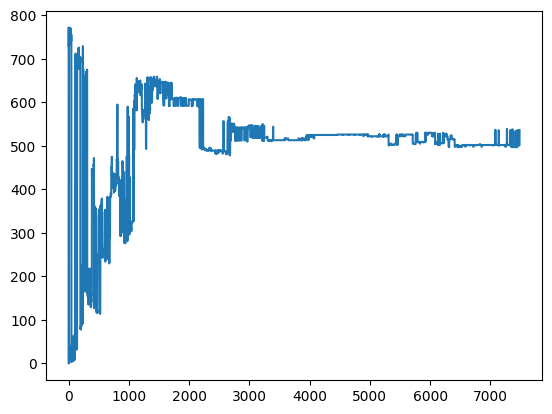

In [141]:
contrib_order_history['order'].plot()

In [53]:
# Get the order over time - Contrib

discounted_contrib_order_history = pd.DataFrame({})
discounted_contrib_order_history['order_list'] = priority_dict['discounted_contrib_training_spring']['order_history']
discounted_contrib_order_history.index = priority_dict['contrib_training_spring']['order_history'].index

discounted_contrib_order_history['order_str'] = discounted_contrib_order_history['order_list'].str.replace('[', '')
discounted_contrib_order_history['order_str'] = discounted_contrib_order_history['order_str'].str.replace(']', '')
discounted_contrib_order_history['order_str'] = discounted_contrib_order_history['order_str'].str.replace('\n', '')
#df_order_history['order_str'] = df_order_history['order_list'].apply(lambda x: ','.join(x))

# Add a column with the order encoded
unique_orders = sorted(set(discounted_contrib_order_history['order_str']))
encoded_orders = {ch: i for i, ch in enumerate(unique_orders)}
discounted_contrib_order_history['order'] = [encoded_orders[i] for i in discounted_contrib_order_history['order_str']]
discounted_contrib_order_history.head(5)

,order_list,order_str,order
0,['ev_12' 'ev_02' 'ev_08' 'ev_03' 'ev_19' 'ev_1...,'ev_12' 'ev_02' 'ev_08' 'ev_03' 'ev_19' 'ev_11...,0
1,['storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev...,'storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev_...,1
2,['storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev...,'storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev_...,1
3,['storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev...,'storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev_...,1
4,['storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev...,'storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev_...,1


In [54]:
discounted_contrib_order_history['order'].value_counts()

order
1    7485
0       1
Name: count, dtype: int64

In [55]:
discounted_contrib_order_history

,order_list,order_str,order
0,['ev_12' 'ev_02' 'ev_08' 'ev_03' 'ev_19' 'ev_1...,'ev_12' 'ev_02' 'ev_08' 'ev_03' 'ev_19' 'ev_11...,0
1,['storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev...,'storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev_...,1
2,['storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev...,'storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev_...,1
3,['storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev...,'storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev_...,1
4,['storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev...,'storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev_...,1
...,...,...,...
7481,['storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev...,'storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev_...,1
7482,['storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev...,'storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev_...,1
7483,['storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev...,'storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev_...,1
7484,['storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev...,'storage_01' 'storage_02' 'ev_03' 'ev_05' 'ev_...,1


<Axes: >

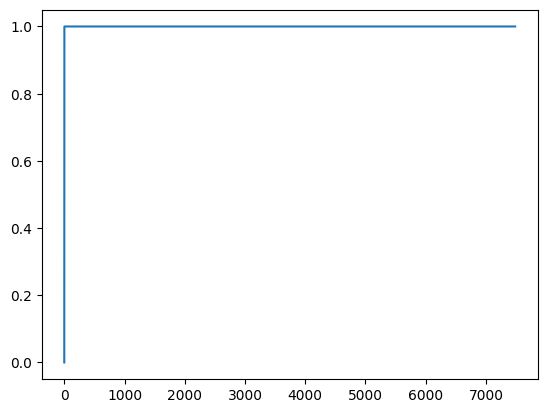

In [56]:
discounted_contrib_order_history['order'].plot()

In [39]:
# Get the order over time - Contrib

urgency_order_history = pd.DataFrame({})
urgency_order_history['order_list'] = priority_dict['urgency_training_spring']['order_history']
urgency_order_history.index = priority_dict['urgency_training_spring']['order_history'].index

urgency_order_history['order_str'] = urgency_order_history['order_list'].str.replace('[', '')
urgency_order_history['order_str'] = urgency_order_history['order_str'].str.replace(']', '')
urgency_order_history['order_str'] = urgency_order_history['order_str'].str.replace('\n', '')
#df_order_history['order_str'] = df_order_history['order_list'].apply(lambda x: ','.join(x))

# Add a column with the order encoded
unique_orders = sorted(set(urgency_order_history['order_str']))
encoded_orders = {ch: i for i, ch in enumerate(unique_orders)}
urgency_order_history['order'] = [encoded_orders[i] for i in urgency_order_history['order_str']]
urgency_order_history.head(5)

,order_list,order_str,order
0,['ev_20' 'ev_17' 'ev_06' 'ev_08' 'ev_02' 'ev_0...,'ev_20' 'ev_17' 'ev_06' 'ev_08' 'ev_02' 'ev_05...,7456
1,['ev_13' 'ev_01' 'ev_10' 'ev_17' 'ev_18' 'ev_2...,'ev_13' 'ev_01' 'ev_10' 'ev_17' 'ev_18' 'ev_20...,109
2,['ev_13' 'ev_01' 'ev_10' 'ev_17' 'ev_16' 'ev_1...,'ev_13' 'ev_01' 'ev_10' 'ev_17' 'ev_16' 'ev_18...,106
3,['ev_13' 'ev_01' 'ev_17' 'ev_10' 'ev_18' 'ev_1...,'ev_13' 'ev_01' 'ev_17' 'ev_10' 'ev_18' 'ev_16...,600
4,['ev_13' 'ev_01' 'ev_17' 'ev_10' 'ev_18' 'ev_1...,'ev_13' 'ev_01' 'ev_17' 'ev_10' 'ev_18' 'ev_16...,597


In [51]:
urgency_order_history.value_counts()

order_list                                                                                                                                                                                                                                                                                                                                                                                                          order_str                                                                                                                                                                                                                                                                                                                                                                                               order
['ev_13' 'ev_01' 'ev_17' 'ev_20' 'ev_10' 'ev_18' 'ev_15' 'ev_16' 'ev_06'\n 'ev_19' 'ev_05' 'ev_11' 'ev_07' 'ev_08' 'ev_03' 'ev_02' 'ev_09' 'ev_12'\n 'storage_19' 'storage_11' 'storage_16' 'storage_1

In [ ]:
'ev_13' 'ev_01' 'ev_17' 'ev_20' 'ev_10' 'ev_18' 'ev_15' 'ev_16' 'ev_06' 'ev_19' 'ev_05' 'ev_11' 'ev_07' 'ev_08' 'ev_03' 'ev_02' 'ev_09' 'ev_12' 'storage_19' 'storage_11' 'storage_16' 'storage_18' 'storage_12' 'storage_06' 'storage_01' 'storage_09' 'storage_20' 'storage_13' 'storage_02' 'storage_08' 'storage_03' 'storage_05' 'storage_07' 'storage_10' 'storage_15' 'storage_17' 'aggregator'

In [ ]:
'ev_13' 'ev_01' 'ev_17' 'ev_20' 'ev_10' 'ev_18' 'ev_09' 'ev_15' 'ev_16' 'ev_11' 'ev_06' 'ev_19' 'ev_05' 'ev_07' 'ev_03' 'ev_08' 'ev_02' 'ev_12' 'storage_19' 'storage_11' 'storage_16' 'storage_18' 'storage_01' 'storage_12' 'storage_09' 'storage_20' 'storage_13' 'storage_06' 'storage_05' 'storage_02' 'storage_17' 'storage_07' 'storage_03' 'storage_08' 'storage_10' 'storage_15' 'aggregator'

<Axes: >

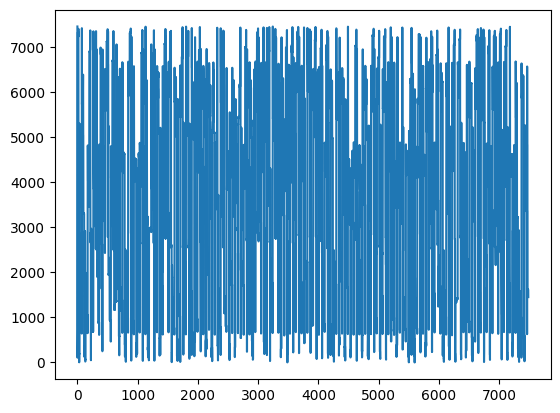

In [44]:
urgency_order_history['order'].plot()